# M1 - 1.1 The Health&Gait Dataset

This notebook gives a brief explanation about the data set Health & Gait


## 1.1.0 Download and access the data

Due to the large size of the dataset, download takes some time. The dataset is provided from 
https://zenodo.org/records/14039922

things from the ReadMe etc.


In [1]:
import pandas as pd

#measures_fp         = "../data/health_and_gait/dataset_samples/patients_measures.csv"
#gait_fp             = "../data/health_and_gait/dataset_samples/gait_parameters_estimation.csv"
#gait_estimation_fp  = "../data/health_and_gait/dataset_samples/gait_parameters.csv"

measures_fp         = "../data/health_and_gait/dataset_set/patients_measures.csv"
gait_fp             = "../data/health_and_gait/dataset_set/gait_parameters_estimation.csv"
gait_estimation_fp  = "../data/health_and_gait/dataset_set/gait_parameters.csv"


df_measures = pd.read_csv(measures_fp)
df_gait = pd.read_csv(gait_fp)
df_gait_estimation = pd.read_csv(gait_estimation_fp)



In [2]:
import matplotlib.pyplot as plt
import numpy as np



## 1.1.2 Identify dataset capabilites

“How accurately can gait parameters be inferred from video-based pose alone, and for whom does it fail?”

“Which health variables most strongly influence gait dynamics?”

“Can we detect abnormal gait patterns without explicit labels?”

## 1.1.1 Brief EDA on Health & Gait 

### Dataset overview

In [3]:
display(df_measures.head())
display(df_gait.head())
display(df_gait_estimation.head())


,ID,Sex,Age,PA_level,Height,Weight,BMI,WaistC,HipC,NeckC,Percentage_fat_mass,Lean_mass,HR_Final
0,PA000,0,25,1.0,158.60,59.75,23.753715,65.50,102.35,29.75,29.4,39.9,NaN
1,PA001,0,22,0.0,156.50,63.35,25.865325,75.65,101.45,32.25,30.3,41.8,188.0
2,PA002,1,27,0.0,169.00,58.35,20.429957,75.00,88.50,37.50,16.4,46.1,171.0
3,PA003,0,26,1.0,171.55,78.35,26.623035,82.15,104.65,35.50,25.4,55.3,180.0
4,PA004,1,21,0.0,179.45,75.20,23.352367,82.50,100.80,39.80,19.3,57.2,203.0


,ID,Velocity_FGS,Step_FGS,Stride_FGS,Cadence_FGS,Velocity_UGS,Step_UGS,Stride_UGS,Cadence_UGS
0,PA000,2.104,79.537,170.101,141.670,1.865,76.242,161.702,133.237
1,PA001,2.162,76.180,165.098,145.781,1.070,55.591,115.599,110.413
2,PA002,2.770,72.939,133.356,197.872,1.689,70.999,126.139,125.989
3,PA003,2.657,78.384,135.026,179.092,1.384,70.765,139.119,118.634
4,PA004,2.031,89.288,191.920,130.782,1.205,69.320,143.833,103.248


,ID,Step_UGS,Stride_UGS,Cadence_UGS,MonoSP_UGS,BiSP_UGS,Velocity_UGS,Step_FGS,Stride_FGS,Cadence_FGS,MonoSP_FGS,BiSP_FGS,Velocity_FGS
0,PA000,54.3,110.5,133.91,0.367,0.166,2.04,54.3,110.5,133.91,0.367,0.166,2.04
1,PA001,33.1,66.8,116.81,0.377,0.285,5.09,57.7,116.5,157.72,0.321,0.140,2.36
2,PA002,40.8,84.3,122.80,0.361,0.251,1.44,58.1,118.5,172.10,0.279,0.123,2.53
3,PA003,45.5,92.0,112.14,0.400,0.299,1.44,57.4,115.7,176.16,0.285,0.113,2.71
4,PA004,46.0,92.7,100.79,0.432,0.325,1.33,66.0,132.0,141.30,0.377,0.099,2.03


### Data quality checks

In [4]:
df_measures.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   398 non-null    object 
 1   Sex                  398 non-null    int64  
 2   Age                  398 non-null    int64  
 3   PA_level             397 non-null    float64
 4   Height               398 non-null    float64
 5   Weight               397 non-null    float64
 6   BMI                  397 non-null    float64
 7   WaistC               398 non-null    float64
 8   HipC                 398 non-null    float64
 9   NeckC                398 non-null    float64
 10  Percentage_fat_mass  397 non-null    float64
 11  Lean_mass            397 non-null    float64
 12  HR_Final             347 non-null    float64
dtypes: float64(10), int64(2), object(1)
memory usage: 40.6+ KB


In [5]:
df_measures.describe()


,Sex,Age,PA_level,Height,Weight,BMI,WaistC,HipC,NeckC,Percentage_fat_mass,Lean_mass,HR_Final
count,398.000000,398.000000,397.000000,398.000000,397.000000,397.000000,398.000000,398.000000,398.000000,397.000000,397.000000,347.000000
mean,0.500000,41.989950,0.511335,168.130402,71.201889,25.035601,83.274246,99.461055,35.302764,25.020277,50.280605,173.155620
std,0.500629,13.121786,0.500502,9.180915,15.638149,4.136122,12.773103,8.773325,3.865090,7.498242,10.618592,13.875957
min,0.000000,19.000000,0.000000,149.000000,41.550000,17.229227,61.000000,50.100000,28.200000,4.800000,27.300000,120.000000
25%,0.000000,30.000000,0.000000,160.850000,59.500000,22.344274,74.150000,94.062500,32.000000,19.000000,41.000000,166.000000
50%,0.500000,43.000000,1.000000,167.975000,69.200000,24.466062,81.250000,98.475000,35.000000,25.000000,48.300000,174.000000
75%,1.000000,54.000000,1.000000,175.150000,79.050000,26.879797,89.975000,103.225000,38.000000,30.000000,58.300000,183.000000
max,1.000000,64.000000,1.000000,192.000000,166.200000,53.960601,138.000000,154.250000,46.000000,47.400000,86.500000,210.000000


In [6]:
df_measures.isna().mean().sort_values(ascending=False)



HR_Final               0.128141
PA_level               0.002513
Weight                 0.002513
BMI                    0.002513
Percentage_fat_mass    0.002513
Lean_mass              0.002513
ID                     0.000000
Sex                    0.000000
Age                    0.000000
Height                 0.000000
WaistC                 0.000000
HipC                   0.000000
NeckC                  0.000000
dtype: float64

In [7]:
missing_frac_measures = df_measures.isna().mean().sort_values(ascending=False)
missing_frac_measures

HR_Final               0.128141
PA_level               0.002513
Weight                 0.002513
BMI                    0.002513
Percentage_fat_mass    0.002513
Lean_mass              0.002513
ID                     0.000000
Sex                    0.000000
Age                    0.000000
Height                 0.000000
WaistC                 0.000000
HipC                   0.000000
NeckC                  0.000000
dtype: float64

---

In [8]:
df_gait_estimation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            398 non-null    object 
 1   Step_UGS      397 non-null    float64
 2   Stride_UGS    397 non-null    float64
 3   Cadence_UGS   397 non-null    float64
 4   MonoSP_UGS    372 non-null    float64
 5   BiSP_UGS      372 non-null    float64
 6   Velocity_UGS  397 non-null    float64
 7   Step_FGS      375 non-null    float64
 8   Stride_FGS    375 non-null    float64
 9   Cadence_FGS   375 non-null    float64
 10  MonoSP_FGS    352 non-null    float64
 11  BiSP_FGS      352 non-null    float64
 12  Velocity_FGS  398 non-null    float64
dtypes: float64(12), object(1)
memory usage: 40.6+ KB


In [9]:
df_gait_estimation.describe()


,Step_UGS,Stride_UGS,Cadence_UGS,MonoSP_UGS,BiSP_UGS,Velocity_UGS,Step_FGS,Stride_FGS,Cadence_FGS,MonoSP_FGS,BiSP_FGS,Velocity_FGS
count,397.000000,397.000000,397.000000,372.000000,372.000000,397.000000,375.000000,375.000000,375.000000,352.000000,352.000000,398.000000
mean,58.165743,117.847103,115.624786,0.392981,0.207532,1.578224,70.927467,145.738133,142.351947,0.328483,0.131619,2.305020
std,13.305157,25.869768,15.954271,0.046960,0.051557,0.284835,13.794902,27.910258,24.327691,0.034188,0.037710,0.365185
min,33.100000,66.800000,49.220000,0.018000,0.020000,0.930000,45.600000,95.000000,32.910000,0.208000,0.024000,1.180000
25%,49.800000,100.700000,107.450000,0.369000,0.172750,1.430000,61.350000,125.650000,127.185000,0.306000,0.106000,2.072500
50%,55.000000,112.200000,116.160000,0.392000,0.208500,1.550000,68.600000,142.200000,142.390000,0.329000,0.130000,2.280000
75%,63.800000,129.800000,124.860000,0.415250,0.243000,1.700000,78.150000,157.600000,156.115000,0.351000,0.155000,2.480000
max,133.500000,238.000000,222.580000,0.592000,0.362000,5.090000,134.300000,307.300000,243.920000,0.432000,0.311000,4.490000


In [10]:
df_gait_estimation.isna().mean().sort_values(ascending=False)

MonoSP_FGS      0.115578
BiSP_FGS        0.115578
MonoSP_UGS      0.065327
BiSP_UGS        0.065327
Step_FGS        0.057789
Stride_FGS      0.057789
Cadence_FGS     0.057789
Step_UGS        0.002513
Stride_UGS      0.002513
Cadence_UGS     0.002513
Velocity_UGS    0.002513
ID              0.000000
Velocity_FGS    0.000000
dtype: float64

In [11]:
missing_frac_gait_estimation = df_gait_estimation.isna().mean().sort_values(ascending=False)
missing_frac_gait_estimation

MonoSP_FGS      0.115578
BiSP_FGS        0.115578
MonoSP_UGS      0.065327
BiSP_UGS        0.065327
Step_FGS        0.057789
Stride_FGS      0.057789
Cadence_FGS     0.057789
Step_UGS        0.002513
Stride_UGS      0.002513
Cadence_UGS     0.002513
Velocity_UGS    0.002513
ID              0.000000
Velocity_FGS    0.000000
dtype: float64

---

In [12]:
df_gait.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            398 non-null    object 
 1   Velocity_FGS  398 non-null    float64
 2   Step_FGS      398 non-null    float64
 3   Stride_FGS    398 non-null    float64
 4   Cadence_FGS   398 non-null    float64
 5   Velocity_UGS  398 non-null    float64
 6   Step_UGS      398 non-null    float64
 7   Stride_UGS    398 non-null    float64
 8   Cadence_UGS   398 non-null    float64
dtypes: float64(8), object(1)
memory usage: 28.1+ KB


In [13]:
df_gait.describe()


,Velocity_FGS,Step_FGS,Stride_FGS,Cadence_FGS,Velocity_UGS,Step_UGS,Stride_UGS,Cadence_UGS
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,2.295510,82.486216,152.141063,147.593239,1.544430,71.704068,136.814930,119.627003
std,0.326011,7.781508,29.336798,15.300356,0.206456,6.730891,21.799472,9.031600
min,1.554000,61.845000,95.441000,110.999000,1.003000,55.591000,82.893000,92.487000
25%,2.095000,76.927000,127.369750,137.311000,1.396500,66.814750,119.988250,113.514250
50%,2.268500,82.116500,154.011500,145.763000,1.530500,71.278500,136.660500,119.081000
75%,2.480500,87.744500,173.709250,155.623750,1.687250,76.131500,151.955000,125.848250
max,4.018000,105.383000,224.528000,229.607000,2.329000,95.590000,201.046000,144.787000


In [14]:
df_gait.isna().mean().sort_values(ascending=False)

ID              0.0
Velocity_FGS    0.0
Step_FGS        0.0
Stride_FGS      0.0
Cadence_FGS     0.0
Velocity_UGS    0.0
Step_UGS        0.0
Stride_UGS      0.0
Cadence_UGS     0.0
dtype: float64

In [15]:
missing_frac_gait = df_gait.isna().mean().sort_values(ascending=False)
missing_frac_gait

ID              0.0
Velocity_FGS    0.0
Step_FGS        0.0
Stride_FGS      0.0
Cadence_FGS     0.0
Velocity_UGS    0.0
Step_UGS        0.0
Stride_UGS      0.0
Cadence_UGS     0.0
dtype: float64

Assumption: patient_id and trial_id are identificatios and are not used as features.

### Subject-level understanding

To understand the dataset, we check how many unique people are in the data set, how many rows per person are recorded and which measurments are per person vs per trail. 
Also it is checked whether data from the sme persion apperars multiple times and whether leakage is possible if split correctly.


This is important, because it prohibits cheating (model sees same person in test and train)

In [16]:
set(df_measures.columns) & set(df_gait_estimation.columns) & set(df_gait.columns)



{'ID'}

---

In [17]:
df_measures.duplicated().any()


False

In [19]:
df_gait_estimation.duplicated().any()

False

In [18]:
df_gait.duplicated().any()

False

---

In [19]:
df_measures['ID'].nunique()
df_gait_estimation['ID'].nunique()
df_gait['ID'].nunique()

398

In [20]:
df_gait['ID'].value_counts().head()


ID
PA000    1
PA273    1
PA271    1
PA270    1
PA269    1
Name: count, dtype: int64

In [21]:
for name, df in {
    "measures": df_measures,
    "gait_gt": df_gait,
    "gait_est": df_gait_estimation
}.items():
    print(name)
    print(df['ID'].value_counts().describe(), "\n")


measures
count    398.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: count, dtype: float64 

gait_gt
count    398.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: count, dtype: float64 

gait_est
count    398.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: count, dtype: float64 



In [22]:
ids_measures = set(df_measures['ID'])
ids_gait = set(df_gait['ID'])
ids_est = set(df_gait_estimation['ID'])

ids_measures - ids_gait      # Personen ohne GT
ids_gait - ids_measures      # Personen ohne Measures
ids_est - ids_gait           # Estimation ohne GT?


set()

In [23]:
df_merged=df_gait.merge(
    df_gait_estimation,
    on="ID",
    suffixes=("_gt", "_est")
)

#.corr(numeric_only=True)['gait_speed_gt'].sort_values(ascending=False)


In [24]:
df_merged

,ID,Velocity_FGS_gt,Step_FGS_gt,Stride_FGS_gt,Cadence_FGS_gt,Velocity_UGS_gt,Step_UGS_gt,Stride_UGS_gt,Cadence_UGS_gt,Step_UGS_est,...,Cadence_UGS_est,MonoSP_UGS,BiSP_UGS,Velocity_UGS_est,Step_FGS_est,Stride_FGS_est,Cadence_FGS_est,MonoSP_FGS,BiSP_FGS,Velocity_FGS_est
0,PA000,2.104,79.537,170.101,141.670,1.865,76.242,161.702,133.237,54.3,...,133.91,0.367,0.166,2.04,54.3,110.5,133.91,0.367,0.166,2.04
1,PA001,2.162,76.180,165.098,145.781,1.070,55.591,115.599,110.413,33.1,...,116.81,0.377,0.285,5.09,57.7,116.5,157.72,0.321,0.140,2.36
2,PA002,2.770,72.939,133.356,197.872,1.689,70.999,126.139,125.989,40.8,...,122.80,0.361,0.251,1.44,58.1,118.5,172.10,0.279,0.123,2.53
3,PA003,2.657,78.384,135.026,179.092,1.384,70.765,139.119,118.634,45.5,...,112.14,0.400,0.299,1.44,57.4,115.7,176.16,0.285,0.113,2.71
4,PA004,2.031,89.288,191.920,130.782,1.205,69.320,143.833,103.248,46.0,...,100.79,0.432,0.325,1.33,66.0,132.0,141.30,0.377,0.099,2.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,PA393,2.596,84.748,185.025,156.513,1.638,75.675,158.856,127.877,48.4,...,124.10,0.392,0.200,1.67,64.2,134.3,164.63,0.308,0.104,3.00
394,PA394,2.249,92.395,169.133,135.424,1.682,77.644,166.177,120.158,62.0,...,123.50,0.386,0.215,1.91,70.5,146.8,147.99,0.358,0.100,2.42
395,PA395,2.624,92.485,200.641,149.950,1.770,84.101,183.836,118.841,66.3,...,128.54,0.398,0.117,2.13,68.2,143.4,167.88,0.318,0.063,2.82
396,PA396,2.117,74.437,158.932,157.905,1.648,70.943,148.454,134.641,64.1,...,117.60,0.340,0.162,1.76,74.0,157.2,127.15,NaN,NaN,2.63


In [25]:

df_num = df_merged.select_dtypes(include="number")
df_num.shape

(398, 20)

In [26]:
identical_pairs = [] #hard leakage 

cols = df_num.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if df_num[c1].equals(df_num[c2]):
            identical_pairs.append((c1, c2))

identical_pairs


[]

USG = unconstrained gait speed
FGS = free gait speed

Tn this subset the coloumns above are either computed with the same algorithm or not acctually varied. To avoid model confidence inflation or feature importance distortion we handle this issue by deciding a canonical column per pair. 

**This means several estimated gait parameters (UGS vs FGS variants) were found to be numerically identical across all samples. These duplicated features were removed to avoid redundancy and instability in downstream models.**

In [27]:
drop_cols = [
    "Step_FGS_est",
    "Stride_FGS_est",
    "Cadence_FGS_est",
    "MonoSP_FGS",
    "BiSP_FGS",
    "Velocity_FGS_est",
]

df_num_clean = df_num.drop(columns=drop_cols)


In [28]:
len(identical_pairs)

0

In [29]:
cols = df_num_clean.columns

In [30]:
near_identical = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if np.allclose(df_num_clean[c1], df_num_clean[c2], rtol=1e-5, atol=1e-8):
            near_identical.append((c1, c2))

near_identical


[]

In [31]:
df[df.isna().any(axis=1)]


,ID,Step_UGS,Stride_UGS,Cadence_UGS,MonoSP_UGS,BiSP_UGS,Velocity_UGS,Step_FGS,Stride_FGS,Cadence_FGS,MonoSP_FGS,BiSP_FGS,Velocity_FGS
8,PA008,85.0,170.0,49.22,NaN,NaN,1.29,NaN,NaN,NaN,NaN,NaN,2.08
9,PA009,58.5,117.0,123.33,0.467,0.141,1.62,NaN,NaN,NaN,NaN,NaN,2.05
10,PA010,53.3,109.0,106.19,NaN,NaN,1.81,NaN,NaN,NaN,NaN,NaN,3.18
11,PA011,54.3,112.0,129.87,NaN,NaN,1.76,NaN,NaN,NaN,NaN,NaN,2.25
12,PA012,55.0,108.5,96.93,NaN,NaN,1.42,NaN,NaN,NaN,NaN,NaN,2.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,PA376,64.3,135.2,118.99,0.411,0.120,1.98,NaN,NaN,NaN,NaN,NaN,2.66
381,PA381,70.8,153.4,104.80,NaN,NaN,1.81,68.7,134.8,176.27,0.262,0.167,2.79
385,PA385,58.6,120.0,106.16,0.423,0.233,1.65,68.7,142.8,194.75,NaN,NaN,2.51
396,PA396,64.1,132.0,117.60,0.340,0.162,1.76,74.0,157.2,127.15,NaN,NaN,2.63


---

In [32]:
num_df = df_num_clean.select_dtypes(include="number")


### Relationship & sanitz checks

feature grouping
How are the features correlated to each other?

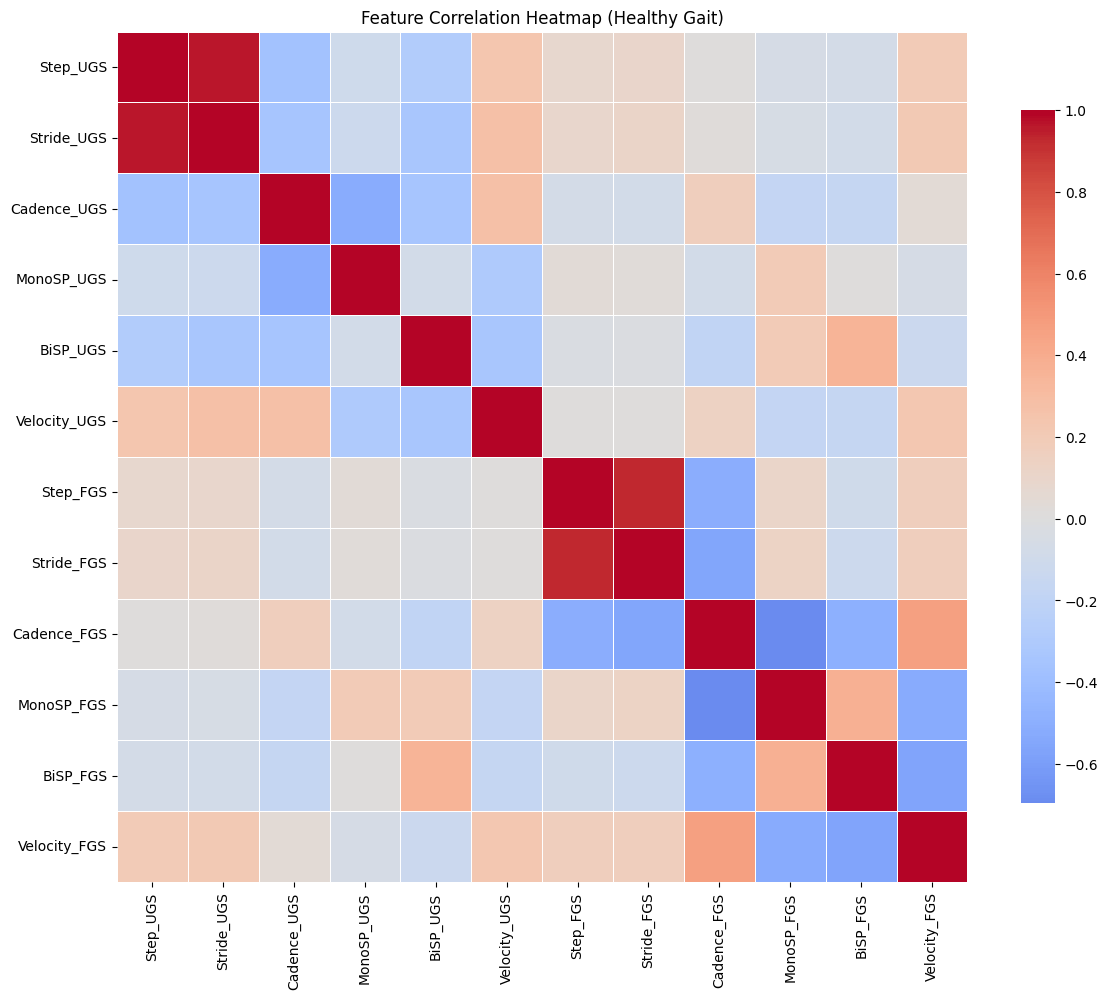

In [33]:

import seaborn as sns

# select numeric gait features only
features = df.select_dtypes(include="number").columns

corr = df[features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Heatmap (Healthy Gait)")
plt.tight_layout()
plt.show()


Redundant features:
Step ↔ Stride (pick one)

Velocity drivers:
Step/stride length (UGS & FGS)
Cadence becomes critical at FGS

Key trade-off:
Cadence ↔ Step/Stride (especially FGS)

Support phases matter:
MonoSP & BiSP encode stability / gait strategy
Cross-speed consistency exists but is not dominant



# quick sanity checks

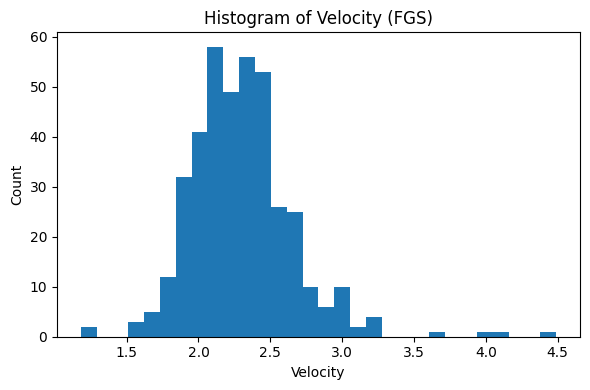

In [54]:
plt.figure(figsize=(6, 4))
plt.hist(
    df["Velocity_FGS"].dropna(),
    bins=30
)
plt.xlabel("Velocity")
plt.ylabel("Count")
plt.title("Histogram of Velocity (FGS)")
plt.tight_layout()
plt.show()


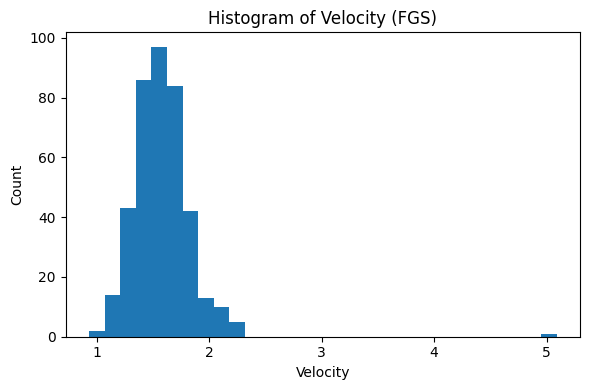

In [55]:
plt.figure(figsize=(6, 4))
plt.hist(
    df["Velocity_UGS"].dropna(),
    bins=30
)
plt.xlabel("Velocity")
plt.ylabel("Count")
plt.title("Histogram of Velocity (FGS)")
plt.tight_layout()
plt.show()


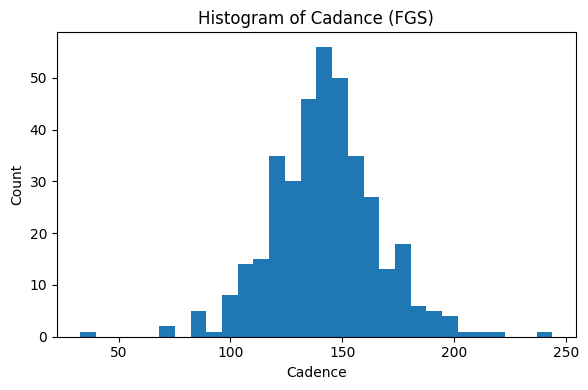

In [57]:
plt.figure(figsize=(6, 4))
plt.hist(
    df["Cadence_FGS"].dropna(),
    bins=30
)
plt.xlabel("Cadence")
plt.ylabel("Count")
plt.title("Histogram of Cadance (FGS)")
plt.tight_layout()
plt.show()


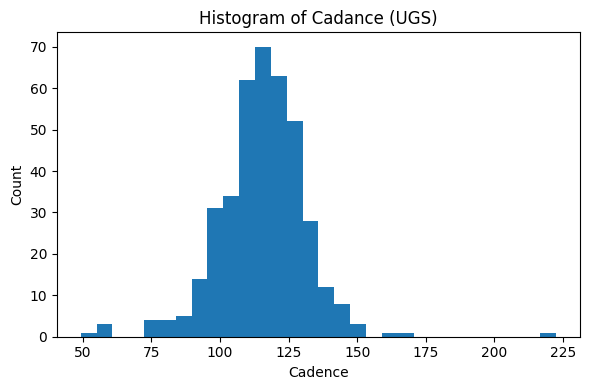

In [58]:
plt.figure(figsize=(6, 4))
plt.hist(
    df["Cadence_UGS"].dropna(),
    bins=30
)
plt.xlabel("Cadence")
plt.ylabel("Count")
plt.title("Histogram of Cadance (UGS)")
plt.tight_layout()
plt.show()

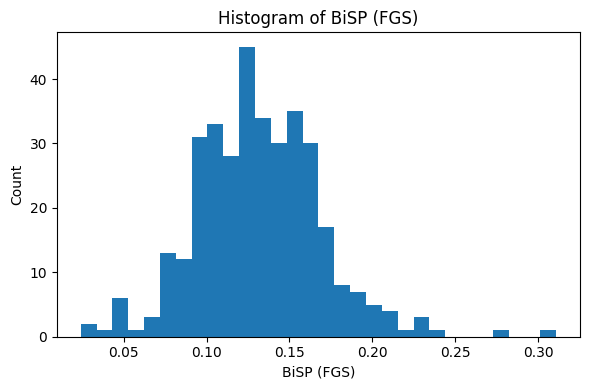

In [59]:
plt.figure(figsize=(6, 4))
plt.hist(
    df["BiSP_FGS"].dropna(),
    bins=30
)
plt.xlabel("BiSP (FGS)")
plt.ylabel("Count")
plt.title("Histogram of BiSP (FGS)")
plt.tight_layout()
plt.show()

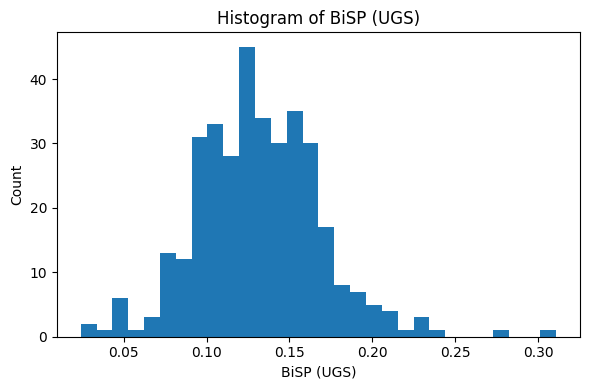

In [60]:
plt.figure(figsize=(6, 4))
plt.hist(
    df["BiSP_FGS"].dropna(),
    bins=30
)
plt.xlabel("BiSP (UGS)")
plt.ylabel("Count")
plt.title("Histogram of BiSP (UGS)")
plt.tight_layout()
plt.show()

# distributions in the features

### Velocity vs Step

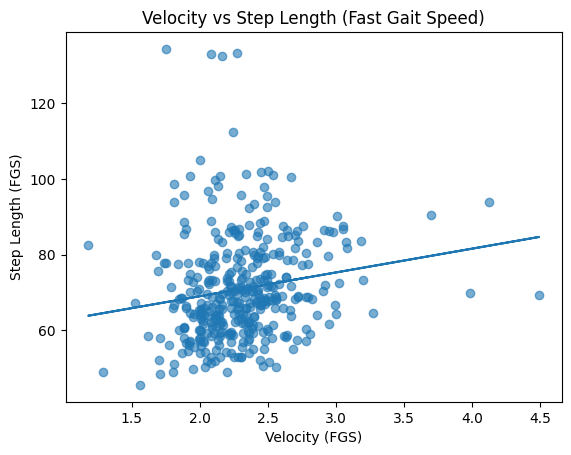

m
6.284529486536028
b
56.446435960101496


In [34]:

x = df['Velocity_FGS']
y = df['Step_FGS']

mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

plt.figure()
plt.scatter(x_clean, y_clean, alpha=0.6)

# linear fit
m, b = np.polyfit(x_clean, y_clean, 1)
plt.plot(x_clean, m * x_clean + b)

plt.xlabel('Velocity (FGS)')
plt.ylabel('Step Length (FGS)')
plt.title('Velocity vs Step Length (Fast Gait Speed)')
plt.show()

print("m")
print(m)

print("b")
print(b)


In [35]:
print(f"Using {len(x_clean)} valid samples out of {len(x)}")


Using 375 valid samples out of 398


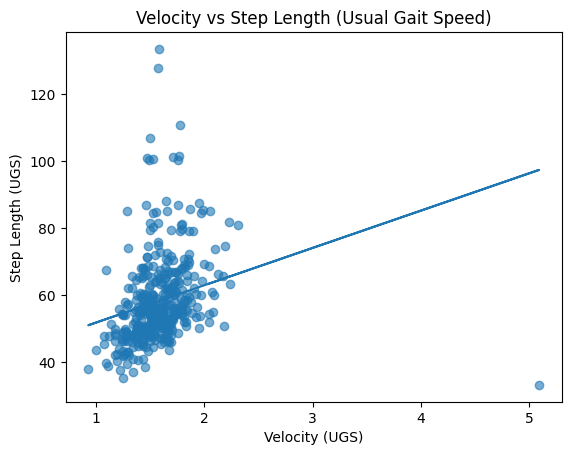

m
11.160850218271387
b
40.546391040000515


In [36]:
x = df['Velocity_UGS']
y = df['Step_UGS']

mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

plt.figure()
plt.scatter(x_clean, y_clean, alpha=0.6)

# linear fit
m, b = np.polyfit(x_clean, y_clean, 1)
plt.plot(x_clean, m * x_clean + b)

plt.xlabel('Velocity (UGS)')
plt.ylabel('Step Length (UGS)')
plt.title('Velocity vs Step Length (Usual Gait Speed)')
plt.show()

print("m")
print(m)

print("b")
print(b)


In [37]:
print(f"Using {len(x_clean)} valid samples out of {len(x)}")

Using 396 valid samples out of 398


how does velocity produced during usual and fast gait? 


### Velocity_FGS vs Cadance_FGS

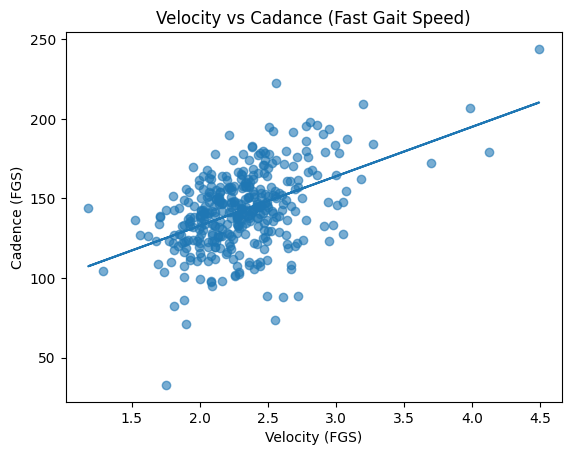

m
31.08202855339988
b
70.73165896359954


In [38]:
x = df['Velocity_FGS']
y = df['Cadence_FGS']

mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

plt.figure()
plt.scatter(x_clean, y_clean, alpha=0.6)

# linear fit
m, b = np.polyfit(x_clean, y_clean, 1)
plt.plot(x_clean, m * x_clean + b)

plt.xlabel('Velocity (FGS)')
plt.ylabel('Cadence (FGS)')
plt.title('Velocity vs Cadance (Fast Gait Speed)')
plt.show()

print("m")
print(m)

print("b")
print(b)

In [39]:
print(f"Using {len(x_clean)} valid samples out of {len(x)}")

Using 375 valid samples out of 398


### Cadance vs Step


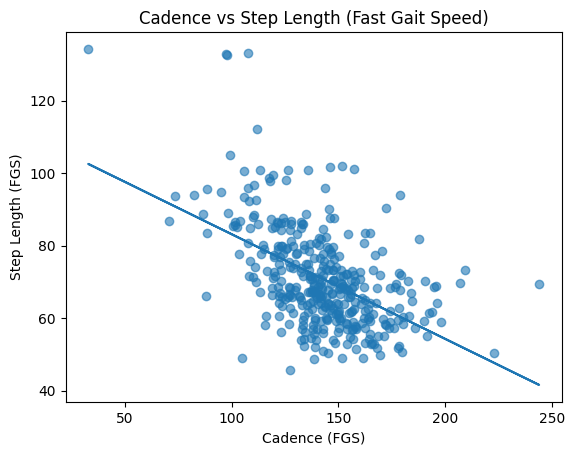

m
-0.2891139924100214
b
112.0834062948051


In [40]:
x = df['Cadence_FGS']
y = df['Step_FGS']

mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

plt.figure()
plt.scatter(x_clean, y_clean, alpha=0.6)

# linear fit
m, b = np.polyfit(x_clean, y_clean, 1)
plt.plot(x_clean, m * x_clean + b)

plt.xlabel('Cadence (FGS)')
plt.ylabel('Step Length (FGS)')
plt.title('Cadence vs Step Length (Fast Gait Speed)')
plt.show()

print("m")
print(m)

print("b")
print(b)

In [41]:
print(f"Using {len(x_clean)} valid samples out of {len(x)}")

Using 375 valid samples out of 398


### Cadence vs BiSP

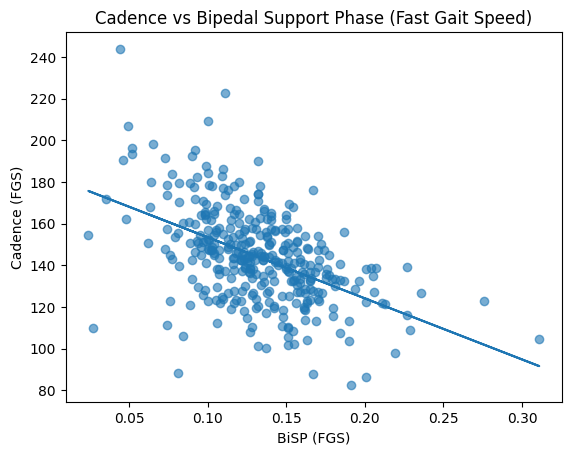

m
-293.05337212149436
b
182.797024802241


In [53]:
x = df['BiSP_FGS']
y = df['Cadence_FGS']

mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

plt.figure()
plt.scatter(x_clean, y_clean, alpha=0.6)

# linear fit
m, b = np.polyfit(x_clean, y_clean, 1)
plt.plot(x_clean, m * x_clean + b)

plt.xlabel('BiSP (FGS)')
plt.ylabel('Cadence (FGS)')
plt.title('Cadence vs Bipedal Support Phase (Fast Gait Speed)')
plt.show()

print("m")
print(m)

print("b")
print(b)

In [43]:
print(f"Using {len(x_clean)} valid samples out of {len(x)}")

Using 352 valid samples out of 398


### Velocity_UGS vs Velocity_FGS

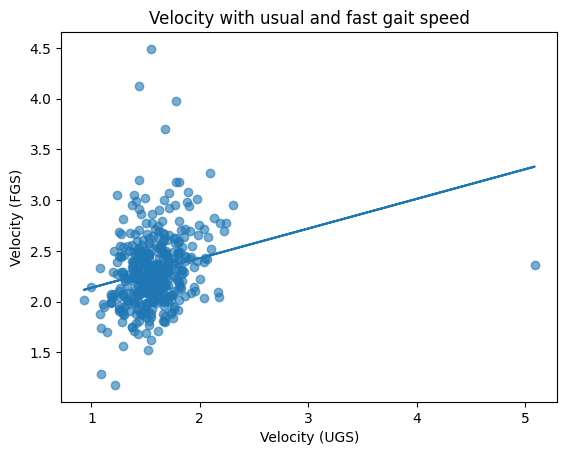

m
0.29197468121248676
b
1.8447098327781122


In [44]:
x = df['Velocity_UGS']
y = df['Velocity_FGS']

mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

plt.figure()
plt.scatter(x_clean, y_clean, alpha=0.6)

# linear fit
m, b = np.polyfit(x_clean, y_clean, 1)
plt.plot(x_clean, m * x_clean + b)

plt.xlabel('Velocity (UGS)')
plt.ylabel('Velocity (FGS)')
plt.title('Velocity with usual and fast gait speed')
plt.show()

print("m")
print(m)

print("b")
print(b)

In [45]:
print(f"Using {len(x_clean)} valid samples out of {len(x)}")

Using 397 valid samples out of 398


In [46]:
features = [
  'Step_UGS',
  'Stride_UGS',
  'Cadence_UGS',
  'MonoSP_UGS',
  'BiSP_UGS',
  'Velocity_UGS',
  'Step_FGS',
  'Stride_FGS',
  'Cadence_FGS',
  'MonoSP_FGS',
  'BiSP_FGS', 
  'Velocity_FGS'
]

normal_values = df[features].median()

df_rel = df.copy()

for f in features:
    df_rel[f + '_rel'] = (df[f] - normal_values[f]) / normal_values[f]


In [48]:
print(normal_values)

Step_UGS         55.0000
Stride_UGS      112.2000
Cadence_UGS     116.1600
MonoSP_UGS        0.3920
BiSP_UGS          0.2085
Velocity_UGS      1.5500
Step_FGS         68.6000
Stride_FGS      142.2000
Cadence_FGS     142.3900
MonoSP_FGS        0.3290
BiSP_FGS          0.1300
Velocity_FGS      2.2800
dtype: float64


As a reasonable referance range the median $\pm$ IQR (Interquartile Range) is used. 

In [49]:
features = [
  'Step_UGS',
  'Stride_UGS',
  'Cadence_UGS',
  'MonoSP_UGS',
  'BiSP_UGS',
  'Velocity_UGS',
  'Step_FGS',
  'Stride_FGS',
  'Cadence_FGS',
  'MonoSP_FGS',
  'BiSP_FGS', 
  'Velocity_FGS'
]

df_clean = df[features].replace([np.inf, -np.inf], np.nan).dropna()

reference = pd.DataFrame(index=features)
reference['median'] = df_clean.median()
reference['q1'] = df_clean.quantile(0.25)
reference['q3'] = df_clean.quantile(0.75)
reference['iqr'] = reference['q3'] - reference['q1']

reference


,median,q1,q3,iqr
Step_UGS,54.600,49.650,62.0000,12.3500
Stride_UGS,111.600,100.200,125.8000,25.6000
Cadence_UGS,116.360,108.125,124.8150,16.6900
MonoSP_UGS,0.393,0.369,0.4160,0.0470
BiSP_UGS,0.210,0.174,0.2435,0.0695
Velocity_UGS,1.540,1.420,1.7000,0.2800
Step_FGS,68.000,60.700,77.5000,16.8000
Stride_FGS,140.200,125.000,154.6000,29.6000
Cadence_FGS,142.950,128.620,156.3400,27.7200
MonoSP_FGS,0.329,0.306,0.3515,0.0455


For each gait parameter, population-based reference values were defined using the median. Normal variability was characterized using the interquartile range (Q1–Q3). Individual gait features were expressed as normalized deviations from the median, scaled by the IQR, and used as input for machine learning models.

In [50]:
df_ref = df.copy()

for f in features:
    df_ref[f + '_refdist'] = (
        (df[f] - reference.loc[f, 'median']) /
        reference.loc[f, 'iqr']
    )


In [51]:
for f in features:
    df_ref[f + '_outlier'] = (
        (df[f] < reference.loc[f, 'q1']) |
        (df[f] > reference.loc[f, 'q3'])
    ).astype(int)


# Outlier removal to normal gait



Varianz-Check (low-variance features)

saubere Baseline-Featureset-Definition

### Dataset Diagnostics (key strengh of this dataset)

- Number of subjects: 398
- Median gait cycles per subject: X
- Features with high intra-subject variability: …
- Strongly correlated feature groups: …
- Most stable gait parameters: …
- Features with estimation failures: …


For each gait parameter, a population-based normal reference value was computed as the median across all participants. Individual features were expressed as relative deviations from this normal value and used as input for machine learning models